In [1]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
class Net(nn.Module):
    def __init__(self, layers=(1, 20, 1)):
        super().__init__()
        net = []
        for i in range(len(layers)-2):
            net.append(nn.Linear(layers[i], layers[i+1]))
            net.append(nn.Tanh())
        net.append(nn.Linear(layers[-2], layers[-1]))
        self.net = nn.Sequential(*net)
    def forward(self, x):
        return self.net(x)

Consider simple ODE:
$$
\begin{cases}
u'' = 2 \\
u(0) = \frac{1}{16} \\
u(1) = \frac{9}{16}
\end{cases}
$$
The solution of the system is $u(x) = (x - \frac{1}{4})^2$

In [3]:
def simulate(layers, epochs):
    # --- Collocation points ---
    N_f = 50
    x_f = torch.rand(N_f, 1, requires_grad=True)

    # --- Boundary points --
    x_bc = torch.cat([torch.zeros(10, 1), torch.ones(10, 1)], dim=0)
    u_bc = torch.cat([torch.full((10, 1), 1.0/16.0), torch.full((10, 1), 9.0/16.0)], dim=0)

    net = Net(layers)

    optimizer = optim.Adam(net.parameters(), lr=1e-3)

    for epoch in range(epochs):
        optimizer.zero_grad()

        # ODE residual
        u_f = net(x_f)
        u_x = torch.autograd.grad(u_f.sum(), x_f, create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_f, torch.ones_like(u_x), create_graph=True)[0]

        loss_ode = torch.mean((u_xx - 2) ** 2)

        # Boundary loss
        u_bc_pred = net(x_bc)
        loss_bc = torch.mean((u_bc_pred - u_bc) ** 2)

        loss = loss_ode + loss_bc
        loss.backward()
        optimizer.step()


    x_test = torch.linspace(0, 1, 100).reshape(-1, 1)
    with torch.no_grad():
        u_pred = net(x_test)
        u_exact = torch.pow(x_test - 1.0/4.0, 2)


    l2_error = torch.norm(u_pred - u_exact)
    l2_relative_error = torch.norm(u_pred - u_exact) / torch.norm(u_exact)
    mse = torch.mean((u_pred - u_exact)**2)
    return l2_error, l2_relative_error, mse

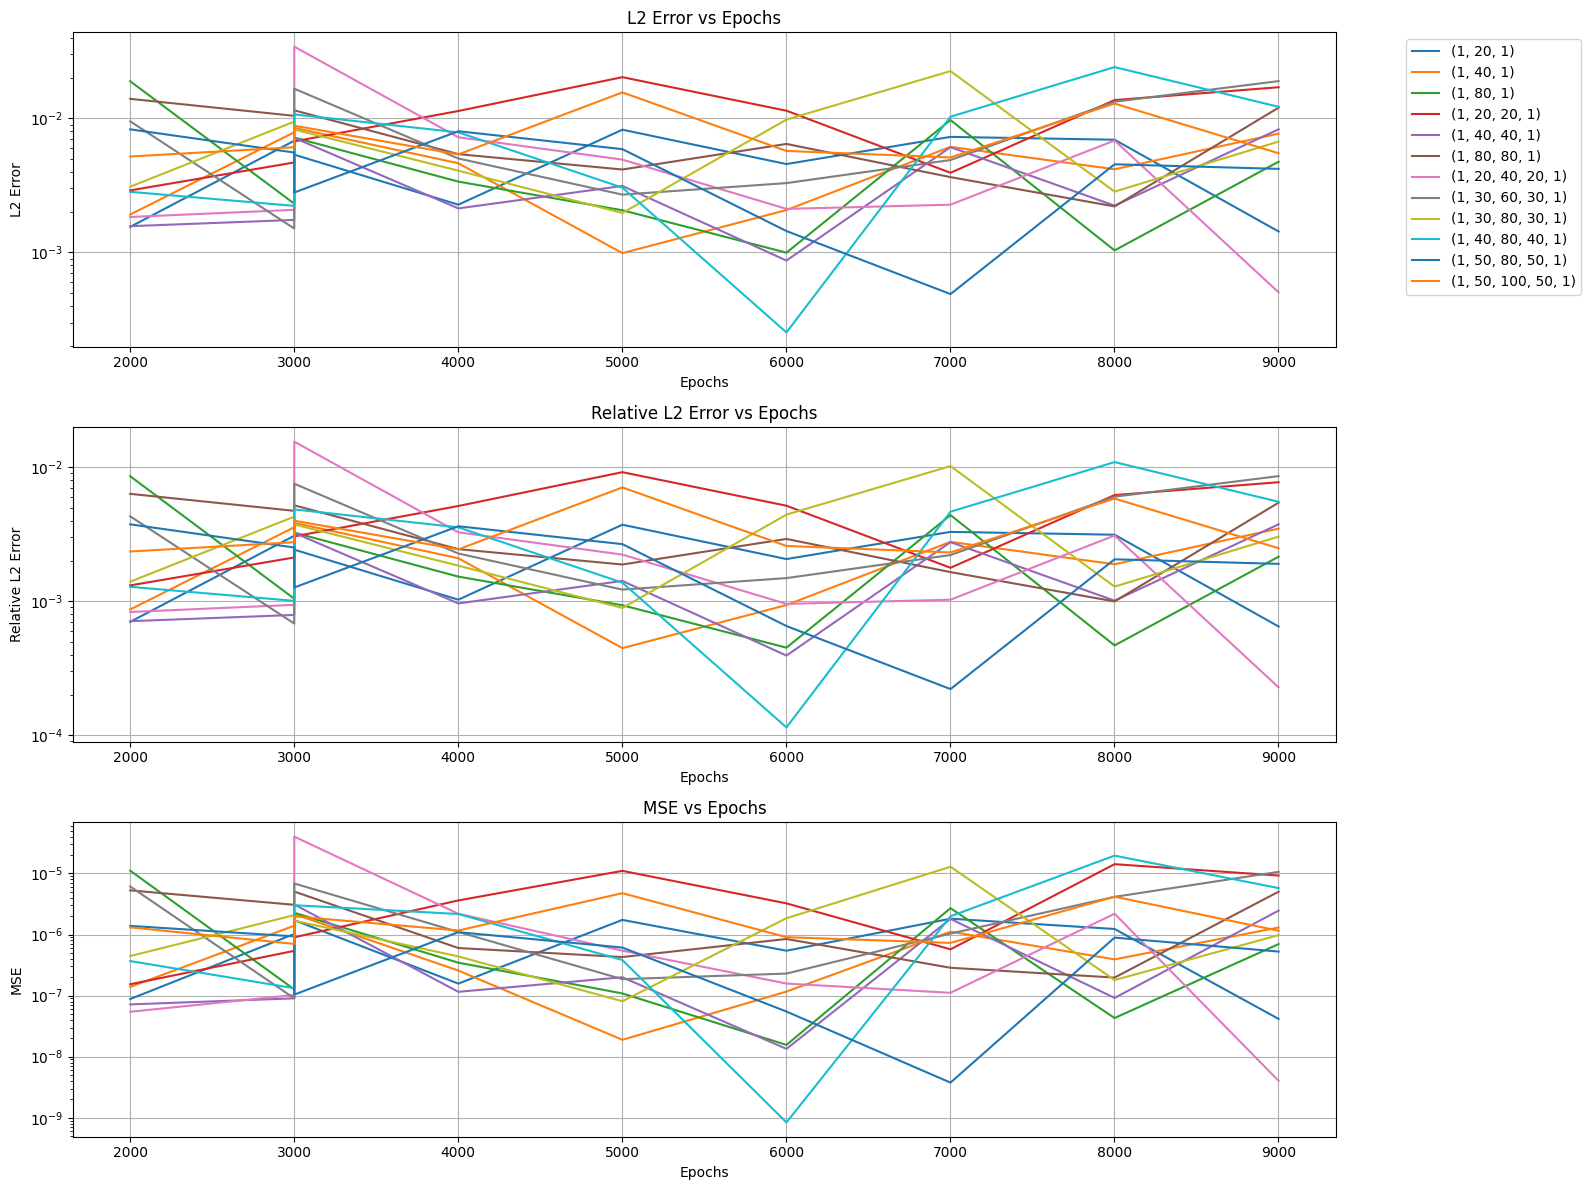

Elapsed time: 12513.86 seconds


In [13]:
import time

# Start timer
start_time = time.time()

structures = [(1, 20, 1), (1, 40, 1), (1, 80, 1), (1, 20, 20, 1), (1, 40, 40, 1), (1, 80, 80, 1),
              (1, 20, 40, 20, 1), (1, 30, 60, 30, 1), (1, 30, 80, 30, 1), (1, 40, 80, 40, 1), (1, 50, 80, 50, 1),
              (1, 50, 100, 50, 1)]

epochs = [2001, 3001, 3001, 4001, 5001, 6001, 7001, 8001, 9001]

results = {}

for structure in structures:
    l2_errors = []
    l2_relative_errors = []
    mses = []

    for epoch in epochs:
        l2_error = []
        l2_relative_error = []
        mse = []
        for i in range(10):
            l2_error_one_step, l2_relative_error_one_step, mse_one_step = simulate(structure, epoch)
            l2_error.append(l2_error_one_step)
            l2_relative_error.append(l2_relative_error_one_step)
            mse.append(mse_one_step)

        # Remove min and max once each
        l2_error.remove(min(l2_error))
        l2_error.remove(max(l2_error))

        l2_relative_error.remove(min(l2_relative_error))
        l2_relative_error.remove(max(l2_relative_error))

        mse.remove(min(mse))
        mse.remove(max(mse))

        # Compute mean of remaining
        l2_errors.append(sum(l2_error)/len(l2_error))
        l2_relative_errors.append(sum(l2_relative_error)/len(l2_relative_error))
        mses.append(sum(mse)/len(mse))

    results[structure] = {
        "l2": l2_errors,
        "l2_rel": l2_relative_errors,
        "mse": mses
    }


plt.figure(figsize=(16, 12))

plt.subplot(3, 1, 1)
for structure, data in results.items():
    plt.semilogy(epochs, data["l2"], label=str(structure))
plt.title("L2 Error vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("L2 Error")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)


plt.subplot(3, 1, 2)
for structure, data in results.items():
    plt.semilogy(epochs, data["l2_rel"], label=str(structure))
plt.title("Relative L2 Error vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Relative L2 Error")
plt.grid(True)


plt.subplot(3, 1, 3)
for structure, data in results.items():
    plt.semilogy(epochs, data["mse"], label=str(structure))
plt.title("MSE vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.grid(True)

plt.tight_layout()
plt.show()

# End timer
end_time = time.time()

# Compute and print elapsed time
elapsed = end_time - start_time
print(f"Elapsed time: {elapsed:.2f} seconds")

Consider the following ODE:
$$
\begin{cases}
u'' = (4\sigma^2(x - x_0)^2 - 2\sigma) e^{-\sigma(x-x_0)^2} \\
u(0) = e^{-\sigma x_0^2} \\
u(x_0) = 1
\end{cases}
$$

The solution is Gaussian function $u(x) = e^{-\sigma(x-x_0)^2}$

We consider the case of $\sigma=1$, $x_0 = 0$, thus system would look like this:
$$
\begin{cases}
u'' = (4x^2 - 2) e^{-x^2} \\
u(0) = 1
\end{cases}
$$
With the solution  $u(x) = e^{-x^2}$
The interval we takes is $x \in [0, 3]$

In [14]:
def simulateGaussian(layers, epochs):
    # --- Collocation points ---
    N_f = 50
    x_f = torch.rand(N_f, 1) * 3.0
    x_f.requires_grad_()
    f = ((4 * torch.pow(x_f, 2) - 2) * torch.exp(-torch.pow(x_f, 2))).detach()


    # --- Boundary points ---
    x_bc = torch.cat([torch.zeros(5, 1), torch.full((5, 1), 3.0)], dim=0)
    u_bc = torch.cat([torch.ones(5, 1), torch.full((5, 1), math.exp(-9))], dim=0)

    net = Net(layers)

    optimizer = optim.Adam(net.parameters(), lr=1e-3)

    for epoch in range(epochs):
        optimizer.zero_grad()

        # ODE residual
        u_f = net(x_f)
        u_x = torch.autograd.grad(u_f.sum(), x_f, create_graph=True)[0]
        u_xx = torch.autograd.grad(u_x, x_f, torch.ones_like(u_x), create_graph=True)[0]

        loss_ode = torch.mean((u_xx - f)**2)

        # Boundary loss
        u_bc_pred = net(x_bc)
        loss_bc = torch.mean((u_bc - u_bc_pred)**2)

        loss = loss_ode + loss_bc
        loss.backward()
        optimizer.step()


    x_test = torch.linspace(0, 3, 100).reshape(-1, 1)
    with torch.no_grad():
        u_pred = net(x_test)
        u_exact = torch.exp(-torch.pow(x_test, 2))


    l2_error = torch.norm(u_pred - u_exact)
    l2_relative_error = torch.norm(u_pred - u_exact) / torch.norm(u_exact)
    mse = torch.mean((u_pred - u_exact)**2)
    return l2_error, l2_relative_error, mse

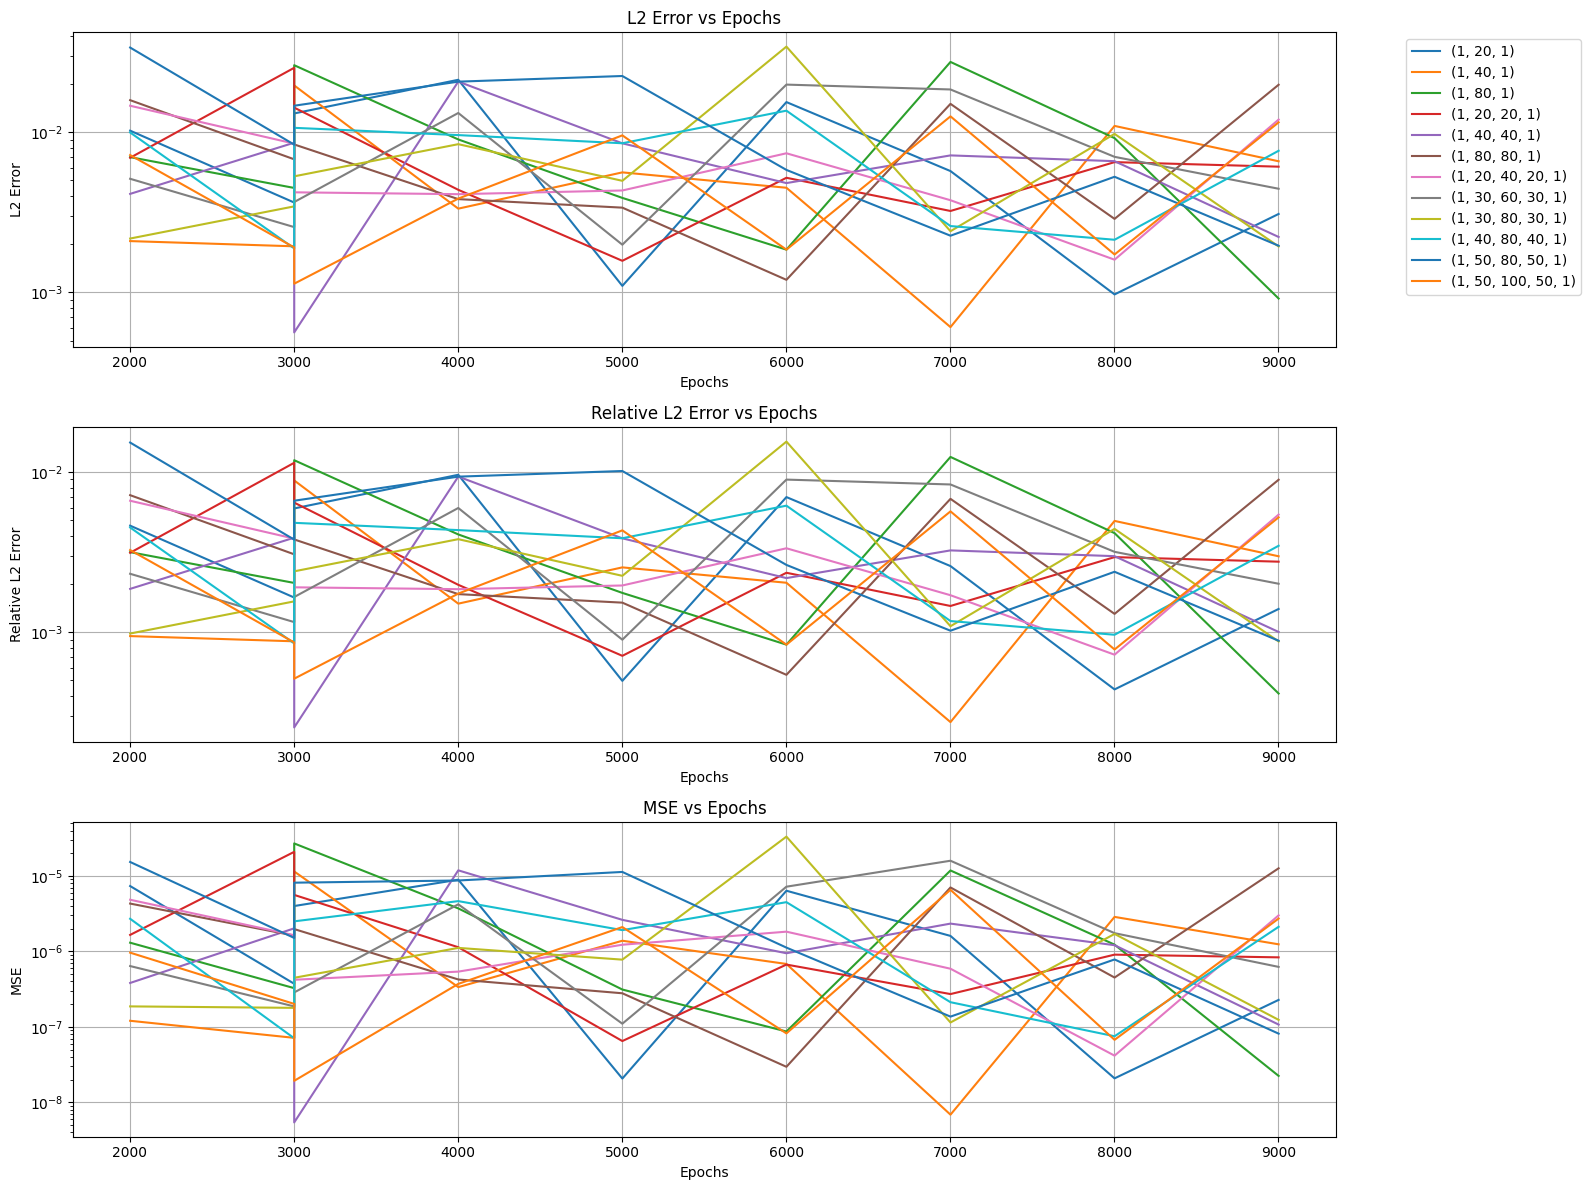

Elapsed time: 5578.22 seconds


In [15]:
# Start timer
start_time = time.time()

structures = [(1, 20, 1), (1, 40, 1), (1, 80, 1), (1, 20, 20, 1), (1, 40, 40, 1), (1, 80, 80, 1),
              (1, 20, 40, 20, 1), (1, 30, 60, 30, 1), (1, 30, 80, 30, 1), (1, 40, 80, 40, 1), (1, 50, 80, 50, 1),
              (1, 50, 100, 50, 1)]

epochs = [2001, 3001, 3001, 4001, 5001, 6001, 7001, 8001, 9001]

results = {}

for structure in structures:
    l2_errors = []
    l2_relative_errors = []
    mses = []

    for epoch in epochs:
        l2_error = []
        l2_relative_error = []
        mse = []
        for i in range(10):
            l2_error_one_step, l2_relative_error_one_step, mse_one_step = simulate(structure, epoch)
            l2_error.append(l2_error_one_step)
            l2_relative_error.append(l2_relative_error_one_step)
            mse.append(mse_one_step)

        # Remove min and max once each
        l2_error.remove(min(l2_error))
        l2_error.remove(max(l2_error))

        l2_relative_error.remove(min(l2_relative_error))
        l2_relative_error.remove(max(l2_relative_error))

        mse.remove(min(mse))
        mse.remove(max(mse))

        # Compute mean of remaining
        l2_errors.append(sum(l2_error)/len(l2_error))
        l2_relative_errors.append(sum(l2_relative_error)/len(l2_relative_error))
        mses.append(sum(mse)/len(mse))

    results[structure] = {
        "l2": l2_errors,
        "l2_rel": l2_relative_errors,
        "mse": mses
    }


plt.figure(figsize=(16, 12))

plt.subplot(3, 1, 1)
for structure, data in results.items():
    plt.semilogy(epochs, data["l2"], label=str(structure))
plt.title("L2 Error vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("L2 Error")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)


plt.subplot(3, 1, 2)
for structure, data in results.items():
    plt.semilogy(epochs, data["l2_rel"], label=str(structure))
plt.title("Relative L2 Error vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Relative L2 Error")
plt.grid(True)


plt.subplot(3, 1, 3)
for structure, data in results.items():
    plt.semilogy(epochs, data["mse"], label=str(structure))
plt.title("MSE vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.grid(True)

plt.tight_layout()
plt.show()

# End timer
end_time = time.time()

# Compute and print elapsed time
elapsed = end_time - start_time
print(f"Elapsed time: {elapsed:.2f} seconds")